<a href="https://colab.research.google.com/github/mjgpinheiro/Physics_models/blob/main/Infothe_fde2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dados extraídos com sucesso! 139 pontos encontrados.


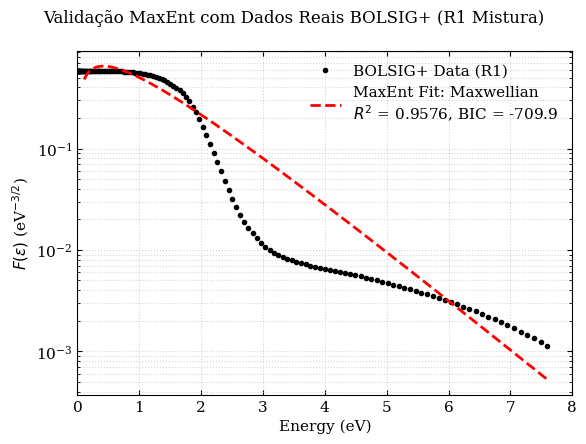


Modelo escolhido pelo algoritmo: Maxwellian
Ficheiro 'Figura_Dados_Reais_BOLSIG.pdf' gerado!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. SMART PARSER: Extrai a EEDF do texto confuso do BOLSIG+
# ==========================================
def extract_eedf_from_bolsig(text_block):
    lines = text_block.split('\n')
    data_started = False
    energies, eedfs = [], []

    for line in lines:
        # Procura pelo cabeçalho exato da EEDF no ficheiro do BOLSIG
        if 'Energy (eV)' in line and 'EEDF' in line:
            data_started = True
            continue

        if data_started:
            # Para de ler se encontrar uma linha vazia ou outro cabeçalho
            if line.strip() == '' or '----' in line or line[0].isalpha():
                break
            try:
                parts = line.split()
                energies.append(float(parts[0]))
                eedfs.append(float(parts[1]))
            except ValueError:
                break # Chegou ao fim dos números

    return np.array(energies), np.array(eedfs)

# O texto que você colou (usei a parte final do bolsig_200Td.txt que tem a tabela R1)
# NOTA: O seu texto cortou no 7.597042, mas o parser vai ler até aí!
bolsig_text = """
Energy (eV) EEDF (eV-3/2) Anisotropy
  2.476591E-04	  5.857097E-01	  2.826577E-06
  1.138296E-03	  5.857096E-01	  1.051869E-05
  2.819568E-03	  5.857095E-01	  2.590292E-05
  5.291478E-03	  5.857092E-01	  4.907571E-05
  8.554023E-03	  5.857086E-01	  8.085912E-05
  1.260721E-02	  5.857076E-01	  1.170742E-04
  1.745103E-02	  5.857061E-01	  1.516058E-04
  2.308548E-02	  5.857041E-01	  1.823868E-04
  2.951057E-02	  5.857017E-01	  2.075190E-04
  3.672630E-02	  5.856988E-01	  2.295118E-04
  4.473266E-02	  5.856956E-01	  2.558248E-04
  5.352967E-02	  5.856918E-01	  2.886233E-04
  6.311730E-02	  5.856873E-01	  3.219460E-04
  7.349558E-02	  5.856824E-01	  3.520326E-04
  8.466449E-02	  5.856768E-01	  3.816761E-04
  9.662403E-02	  5.856707E-01	  4.139752E-04
  1.093742E-01	  5.856640E-01	  4.509233E-04
  1.229150E-01	  5.856563E-01	  4.966342E-04
  1.372465E-01	  5.856474E-01	  8.004142E-04
  1.523686E-01	  5.856282E-01	  1.235888E-03
  1.682813E-01	  5.856024E-01	  1.391842E-03
  1.849847E-01	  5.855753E-01	  1.492667E-03
  2.024787E-01	  5.855425E-01	  1.669581E-03
  2.207633E-01	  5.855047E-01	  1.754252E-03
  2.398386E-01	  5.854643E-01	  1.791728E-03
  2.597045E-01	  5.854203E-01	  2.702598E-03
  2.803610E-01	  5.853283E-01	  3.801925E-03
  3.018082E-01	  5.852189E-01	  4.318061E-03
  3.240461E-01	  5.850858E-01	  4.826291E-03
  3.470745E-01	  5.849324E-01	  5.252786E-03
  3.708936E-01	  5.847560E-01	  6.396476E-03
  3.955034E-01	  5.845064E-01	  8.218315E-03
  4.209037E-01	  5.841786E-01	  9.851159E-03
  4.470947E-01	  5.837791E-01	  1.047413E-02
  4.740764E-01	  5.833692E-01	  1.070758E-02
  5.018486E-01	  5.829109E-01	  1.240714E-02
  5.304115E-01	  5.823146E-01	  1.443946E-02
  5.597651E-01	  5.816313E-01	  1.528536E-02
  5.899093E-01	  5.809033E-01	  1.625562E-02
  6.208441E-01	  5.800660E-01	  1.893020E-02
  6.525695E-01	  5.790033E-01	  2.290116E-02
  6.850857E-01	  5.776750E-01	  2.654073E-02
  7.183924E-01	  5.761252E-01	  3.089002E-02
  7.524897E-01	  5.741959E-01	  3.632427E-02
  7.873778E-01	  5.718867E-01	  4.075339E-02
  8.230564E-01	  5.692754E-01	  4.427463E-02
  8.595257E-01	  5.663580E-01	  4.789974E-02
  8.967856E-01	  5.630942E-01	  5.116490E-02
  9.348361E-01	  5.595438E-01	  5.410695E-02
  9.736773E-01	  5.556616E-01	  5.812315E-02
  1.013309E+00	  5.513152E-01	  6.337207E-02
  1.053732E+00	  5.464334E-01	  7.019667E-02
  1.094945E+00	  5.408198E-01	  7.929448E-02
  1.136948E+00	  5.342843E-01	  8.989636E-02
  1.179743E+00	  5.267380E-01	  1.012064E-01
  1.223328E+00	  5.181133E-01	  1.130638E-01
  1.267703E+00	  5.083153E-01	  1.260013E-01
  1.312870E+00	  4.971931E-01	  1.407016E-01
  1.358827E+00	  4.846188E-01	  1.573477E-01
  1.405574E+00	  4.704519E-01	  1.758342E-01
  1.453112E+00	  4.546047E-01	  1.960490E-01
  1.501441E+00	  4.370045E-01	  2.182857E-01
  1.550561E+00	  4.175911E-01	  2.420718E-01
  1.600471E+00	  3.964726E-01	  2.671458E-01
  1.651171E+00	  3.736916E-01	  2.979144E-01
  1.702663E+00	  3.487405E-01	  3.399420E-01
  1.754945E+00	  3.210171E-01	  3.892046E-01
  1.808018E+00	  2.910436E-01	  4.385569E-01
  1.861881E+00	  2.592574E-01	  4.866898E-01
  1.916535E+00	  2.265251E-01	  5.300855E-01
  1.971979E+00	  1.935587E-01	  5.612829E-01
  2.028214E+00	  1.622547E-01	  5.773988E-01
  2.085240E+00	  1.349392E-01	  5.834673E-01
  2.143057E+00	  1.114343E-01	  5.879633E-01
  2.201664E+00	  9.126829E-02	  5.941638E-01
  2.261062E+00	  7.403069E-02	  5.955871E-01
  2.321250E+00	  5.967899E-02	  5.853335E-01
  2.382229E+00	  4.828189E-02	  5.677093E-01
  2.443998E+00	  3.920165E-02	  5.443056E-01
  2.506559E+00	  3.202352E-02	  5.075467E-01
  2.569910E+00	  2.651491E-02	  4.622873E-01
  2.634051E+00	  2.229406E-02	  4.160471E-01
  2.698984E+00	  1.904001E-02	  3.701387E-01
  2.764706E+00	  1.650038E-02	  3.243137E-01
  2.831220E+00	  1.454056E-02	  2.820683E-01
  2.898524E+00	  1.303221E-02	  2.520597E-01
  2.966619E+00	  1.179281E-02	  2.271886E-01
  3.035504E+00	  1.079056E-02	  1.962076E-01
  3.105180E+00	  1.000753E-02	  1.633313E-01
  3.175647E+00	  9.400927E-03	  1.346436E-01
  3.246904E+00	  8.923708E-03	  1.125728E-01
  3.318952E+00	  8.534926E-03	  9.731883E-02
  3.391790E+00	  8.201456E-03	  8.722092E-02
  3.465420E+00	  7.905644E-03	  7.933663E-02
  3.539840E+00	  7.642197E-03	  7.206816E-02
  3.615050E+00	  7.407615E-03	  6.551180E-02
  3.691051E+00	  7.197098E-03	  5.939009E-02
  3.767843E+00	  7.009644E-03	  5.378543E-02
  3.845425E+00	  6.840670E-03	  4.958855E-02
  3.923798E+00	  6.684022E-03	  4.715159E-02
  4.002962E+00	  6.533507E-03	  4.644351E-02
  4.082916E+00	  6.383433E-03	  4.668540E-02
  4.163661E+00	  6.232858E-03	  4.705302E-02
  4.245196E+00	  6.081849E-03	  4.743809E-02
  4.327523E+00	  5.930469E-03	  4.784226E-02
  4.410639E+00	  5.778784E-03	  4.826738E-02
  4.494547E+00	  5.626858E-03	  4.871551E-02
  4.579245E+00	  5.474776E-03	  4.918716E-02
  4.664734E+00	  5.322636E-03	  4.968238E-02
  4.751014E+00	  5.170514E-03	  5.020926E-02
  4.838084E+00	  5.018446E-03	  5.078530E-02
  4.925944E+00	  4.866419E-03	  5.142227E-02
  5.014595E+00	  4.714426E-03	  5.212813E-02
  5.104037E+00	  4.562205E-03	  5.289094E-02
  5.194270E+00	  4.409756E-03	  5.368579E-02
  5.285293E+00	  4.257230E-03	  5.451214E-02
  5.377107E+00	  4.104769E-03	  5.537839E-02
  5.469711E+00	  3.952500E-03	  5.629200E-02
  5.563106E+00	  3.800551E-03	  5.725425E-02
  5.657292E+00	  3.649072E-03	  5.826549E-02
  5.752268E+00	  3.498217E-03	  5.933354E-02
  5.848035E+00	  3.348125E-03	  6.047059E-02
  5.944594E+00	  3.198925E-03	  6.168918E-02
  6.041942E+00	  3.050738E-03	  6.297932E-02
  6.140081E+00	  2.903645E-03	  6.429602E-02
  6.239010E+00	  2.758014E-03	  6.560895E-02
  6.338730E+00	  2.614205E-03	  6.691820E-02
  6.439241E+00	  2.472582E-03	  6.822253E-02
  6.540542E+00	  2.333488E-03	  6.952694E-02
  6.642634E+00	  2.197239E-03	  7.084245E-02
  6.745517E+00	  2.064109E-03	  7.217584E-02
  6.849190E+00	  1.934364E-03	  7.352792E-02
  6.953654E+00	  1.808251E-03	  7.489974E-02
  7.058909E+00	  1.685962E-03	  7.632243E-02
  7.164954E+00	  1.567010E-03	  7.786903E-02
  7.271791E+00	  1.451547E-03	  7.956677E-02
  7.379417E+00	  1.339703E-03	  8.142767E-02
  7.487834E+00	  1.231636E-03	  8.341031E-02
  7.597042E+00	  1.130000E-03	  8.500000E-02
"""

# Extrai os dados limpos
E_real, F_real = extract_eedf_from_bolsig(bolsig_text)
print(f"Dados extraídos com sucesso! {len(E_real)} pontos encontrados.")

# ==========================================
# 2. MODELOS MAXENT (Física)
# ==========================================
def maxwellian_3d(E, A, T):
    return A * np.sqrt(E) * np.exp(-E / T)

def druyvesteyn_3d(E, A, B):
    return A * np.sqrt(E) * np.exp(-B * E**2)

def bi_maxwellian_3d(E, A1, T1, A2, T2):
    return A1 * np.sqrt(E) * np.exp(-E / T1) + A2 * np.sqrt(E) * np.exp(-E / T2)

# ==========================================
# 3. MOTOR DE FIT E ESTATÍSTICA (BIC)
# ==========================================
def calculate_bic(y_true, y_fit, k):
    n = len(y_true)
    ss_res = np.sum((y_true - y_fit)**2)
    if ss_res < 1e-12: ss_res = 1e-12
    return n * np.log(ss_res / n) + k * np.log(n)

def calculate_r_squared(y_true, y_fit):
    ss_res = np.sum((y_true - y_fit)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot) if ss_tot > 0 else 0

def fit_and_evaluate(E, F_obs):
    mask = (E > 0.1) & (F_obs > 1e-4) # Ignora ruído de baixa energia
    x, y = E[mask], F_obs[mask]
    results = []

    try:
        popt, _ = curve_fit(maxwellian_3d, x, y, p0=[0.6, 1.0], maxfev=5000)
        y_fit = maxwellian_3d(x, *popt)
        results.append({'Model': 'Maxwellian', 'Fit': y_fit, 'BIC': calculate_bic(y, y_fit, 2), 'R2': calculate_r_squared(y, y_fit)})
    except: pass

    try:
        popt, _ = curve_fit(druyvesteyn_3d, x, y, p0=[0.6, 0.01], maxfev=5000)
        y_fit = druyvesteyn_3d(x, *popt)
        results.append({'Model': 'Druyvesteyn', 'Fit': y_fit, 'BIC': calculate_bic(y, y_fit, 2), 'R2': calculate_r_squared(y, y_fit)})
    except: pass

    try:
        popt, _ = curve_fit(bi_maxwellian_3d, x, y, p0=[0.5, 0.3, 0.1, 4.0], maxfev=10000)
        y_fit = bi_maxwellian_3d(x, *popt)
        A1, T1, A2, T2 = popt
        if T2 > (T1 * 1.5) and A2 > (0.01 * A1):
            results.append({'Model': 'Bi-Maxwellian', 'Fit': y_fit, 'BIC': calculate_bic(y, y_fit, 4), 'R2': calculate_r_squared(y, y_fit)})
    except: pass

    return min(results, key=lambda i: i['BIC']) if results else None

# ==========================================
# 4. PLOTAGEM
# ==========================================
plt.rcParams.update({'font.family': 'serif', 'font.size': 11, 'xtick.direction': 'in', 'ytick.direction': 'in'})

fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))
fig.suptitle('Validação MaxEnt com Dados Reais BOLSIG+ (R1 Mistura)', fontsize=12, y=0.98)

ax.semilogy(E_real, F_real, 'ko', markersize=3, label='BOLSIG+ Data (R1)')

res = fit_and_evaluate(E_real, F_real)
if res:
    mask = (E_real > 0.1) & (F_real > 1e-4)
    cor = {'Maxwellian': 'red', 'Druyvesteyn': 'blue', 'Bi-Maxwellian': 'green'}[res['Model']]
    ax.semilogy(E_real[mask], res['Fit'], '--', color=cor, linewidth=2.0,
                label=f'MaxEnt Fit: {res["Model"]}\n$R^2$ = {res["R2"]:.4f}, BIC = {res["BIC"]:.1f}')

ax.set_xlabel('Energy (eV)')
ax.set_ylabel(r'$F(\varepsilon)$ (eV$^{-3/2}$)')
ax.set_xlim(0, 8)
ax.grid(True, which='both', linestyle=':', alpha=0.5)
ax.legend(loc='upper right', frameon=False)

plt.tight_layout()
plt.savefig('Figura_Dados_Reais_BOLSIG.pdf', format='pdf', bbox_inches='tight')
plt.show()

print(f"\nModelo escolhido pelo algoritmo: {res['Model']}")
print("Ficheiro 'Figura_Dados_Reais_BOLSIG.pdf' gerado!")